In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
members_df = pd.read_csv('members.csv')
members_df

,guestID,visitDate,gender,age,married,pool,gym,status,endDate
0,6,2015-01-05,M,47,M,n,y,inactive,2017-08-01
1,7,2015-01-05,F,46,S,n,y,inactive,2016-11-01
2,10,2015-01-06,M,61,S,y,n,inactive,2016-12-01
3,17,2015-01-09,F,36,S,y,n,inactive,2017-01-01
4,24,2015-01-13,M,45,M,y,n,inactive,2016-09-01
...,...,...,...,...,...,...,...,...,...
866,2781,2019-11-12,M,44,M,n,y,active,NaN
867,2783,2019-11-14,F,52,S,n,y,active,NaN
868,2790,2019-11-23,F,38,S,n,y,active,NaN
869,2800,2019-12-04,M,58,S,n,y,active,NaN


In [3]:
members_df.head()

,guestID,visitDate,gender,age,married,pool,gym,status,endDate
0,6,2015-01-05,M,47,M,n,y,inactive,2017-08-01
1,7,2015-01-05,F,46,S,n,y,inactive,2016-11-01
2,10,2015-01-06,M,61,S,y,n,inactive,2016-12-01
3,17,2015-01-09,F,36,S,y,n,inactive,2017-01-01
4,24,2015-01-13,M,45,M,y,n,inactive,2016-09-01


The head() command shows the first few rows of the dataset. This helps me understand what the data looks like and what values are in each column.

In [5]:
members_df.tail()

,guestID,visitDate,gender,age,married,pool,gym,status,endDate
866,2781,2019-11-12,M,44,M,n,y,active,NaN
867,2783,2019-11-14,F,52,S,n,y,active,NaN
868,2790,2019-11-23,F,38,S,n,y,active,NaN
869,2800,2019-12-04,M,58,S,n,y,active,NaN
870,2808,2019-12-18,M,42,S,n,y,active,NaN


In [6]:
members_df.shape

(871, 9)

The dataset contains 871 rows and 9 columns.

In [7]:
members_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 871 entries, 0 to 870
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   guestID    871 non-null    int64 
 1   visitDate  871 non-null    object
 2   gender     871 non-null    object
 3   age        871 non-null    int64 
 4   married    871 non-null    object
 5   pool       871 non-null    object
 6   gym        871 non-null    object
 7   status     871 non-null    object
 8   endDate    723 non-null    object
dtypes: int64(2), object(7)
memory usage: 61.4+ KB


The info() command shows the structure of the dataset, including column names, data types, and non-null values. This helps identify missing data and incorrect data types.

In [8]:
members_df.isna().sum()

guestID        0
visitDate      0
gender         0
age            0
married        0
pool           0
gym            0
status         0
endDate      148
dtype: int64

This shows how many missing values are in each column. The endDate column has missing values, which could affect analysis.

In [9]:
members_df.describe()

,guestID,age
count,871.000000,871.000000
mean,1276.594719,45.840413
std,798.582275,14.346164
min,6.000000,18.000000
25%,596.500000,34.000000
50%,1205.000000,45.000000
75%,1952.000000,58.000000
max,2808.000000,84.000000


The describe() command provides summary statistics for numerical columns like age and guestID. Age is useful for analysis, but guestID is just an identifier.

Data Quality Issues:

1. Missing Values:
The endDate column has 148 missing values. This is a problem because missing data can lead to incomplete or inaccurate analysis.

2. Data Type Issues:
The visitDate and endDate columns are stored as objects instead of datetime. This can cause problems when trying to analyze trends over time.

Column That May Cause Problems:
The guestID column may cause issues because it is only an identifier and does not provide meaningful insights for analysis.

Why These Issues Matter:
These issues matter because poor data quality can lead to incorrect conclusions. Missing values and incorrect data types can reduce the accuracy and reliability of the analysis.

In [10]:
subset = members_df.iloc[0:20, [2,3,4,7]]
subset

,gender,age,married,status
0,M,47,M,inactive
1,F,46,S,inactive
2,M,61,S,inactive
3,F,36,S,inactive
4,M,45,M,inactive
5,F,70,S,inactive
6,M,30,S,inactive
7,M,37,S,inactive
8,F,43,S,inactive
9,F,32,S,inactive


I selected rows 0 to 19 and columns related to gender, age, married, and status. This subset is meaningful because it allows analysis of member demographics and membership status. These variables help understand patterns such as how age or marital status relates to whether a member is active or inactive.

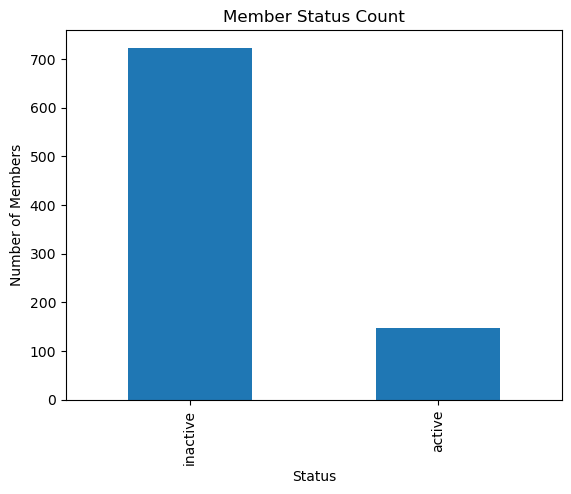

In [11]:
members_df['status'].value_counts().plot(kind='bar')

plt.title('Member Status Count')
plt.xlabel('Status')
plt.ylabel('Number of Members')
plt.show()

I chose a bar chart because it is useful for comparing categories. This chart shows the number of active and inactive members. It helps identify which group is larger and understand overall membership patterns.

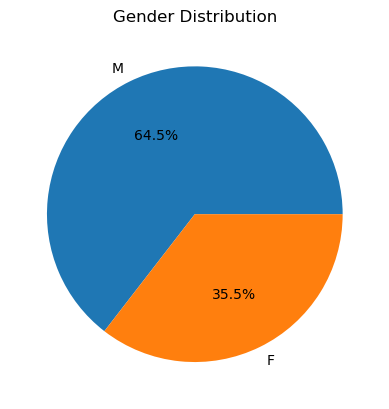

In [12]:
members_df['gender'].value_counts().plot(kind='pie', autopct='%1.1f%%')

plt.title('Gender Distribution')
plt.ylabel('')
plt.show()

The percentages represent the proportion of each gender in the dataset. A pie chart is appropriate here because it clearly shows how the dataset is divided between categories. It is useful when comparing parts of a whole.

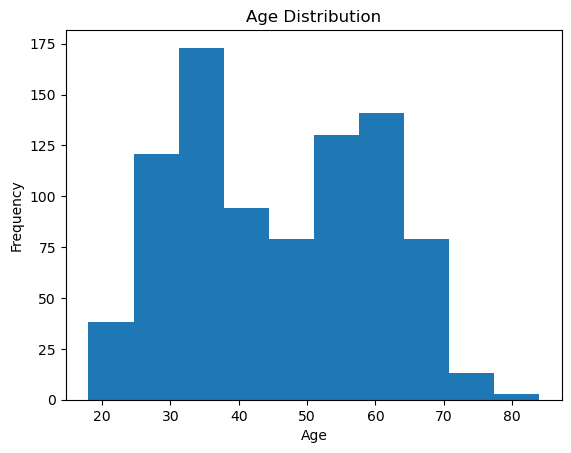

In [13]:
members_df['age'].plot(kind='hist', bins=10)

plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

The histogram shows the distribution of ages in the dataset. Most members appear to be middle-aged, with fewer very young or very old members. This helps understand how the data is spread and identify any patterns or outliers.